# 7.6.2 RTS平滑与连续缺测

## 学习目标与先修知识

推导线性高斯后向平滑，检验末端一致性、缺测和联合条件参照。

先修：7.3的条件Gaussian和KF，以及7.6.1的未来信息与末端条件。 [本篇学习次序](../README.md)。

## 具体问题

第一室传感器连续丢失三个读数后恢复。怎样利用后来读数重建缺测段，并从另一条数学路径核对整个递推？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "DejaVu Sans"]

## 初步实验

In [2]:
print('单时刻、没有未来读数：平滑必须等于滤波。')

单时刻、没有未来读数：平滑必须等于滤波。


## 模型假设

同一已知线性高斯二室模型（model）、同一观测（observation）集；预测协方差（covariance）正定（positive definite），可解后向线性方程。固定区间平滑（fixed-interval smoothing）只用于离线重建。真值不进入滤波或平滑。全缺测时只剩动态先验（prior），平滑不能创造观测信息。

## 数学解释与推导

给定截至t的观测，$(x_t,x_{t+1})$ 联合Gaussian的交叉协方差为 $P_tF^T$。条件于下一状态（state）：
$$E[x_t\mid x_{t+1},y_{0:t}]=m_t+G_t(x_{t+1}-m_{t+1}^-),\quad G_t=P_tF^T(P_{t+1}^-)^{-1}.$$
再对未来观测条件下的下一状态分布（distribution）取期望（expectation）与全方差（variance），得到 Rauch–Tung–Striebel平滑（RTS smoother）：
$$m_t^s=m_t+G_t(m_{t+1}^s-m_{t+1}^-),$$
$$P_t^s=P_t+G_t(P_{t+1}^s-P_{t+1}^-)G_t^T.$$
从 $m_{T-1}^s=m_{T-1},P_{T-1}^s=P_{T-1}$ 反向计算。注意预测索引是t+1；误用t会破坏条件关系。共同正确模型下 $P_t-P_t^s$ 半正定（positive semidefinite），但不保证每次随机实现的实际误差都变小。

独立核验可以一次构造所有 $x_0,\ldots,x_{T-1}$ 的联合Gaussian，再选择已观测时刻组成Y，直接用分块条件公式计算 $p(X\mid Y)$。它计算更昂贵，却不使用滤波或平滑递推，适合小序列验证。

## 核心实现

下面按推导写出计算步骤；函数的输入（input）只包含模型与当时可用的信息。

In [3]:
def kalman_filter(transition, sensor, process_covariance, measurement_variance,
                  initial_mean, initial_covariance, observations):
    F, H, Q = map(lambda x: np.array(x, float), (transition, sensor, process_covariance))
    mean, covariance = np.array(initial_mean, float), np.array(initial_covariance, float)
    result = dict(predicted_means=[], predicted_covariances=[], means=[], covariances=[], innovations=[], innovation_variances=[])
    for t, observed in enumerate(observations):
        if t:
            mean, covariance = F @ mean, F @ covariance @ F.T + Q
        result['predicted_means'].append(mean.tolist())
        result['predicted_covariances'].append(covariance.tolist())
        innovation_variance = float(H @ covariance @ H + measurement_variance)
        innovation = None if observed is None else float(observed - H @ mean)
        if observed is not None:
            gain = covariance @ H / innovation_variance
            mean = mean + gain * innovation
            # Joseph形式保留测量噪声项；数学上等于P-KSKᵀ。
            residual_map = np.eye(len(mean)) - np.outer(gain, H)
            covariance = residual_map @ covariance @ residual_map.T + np.outer(gain, gain) * measurement_variance
            covariance = (covariance + covariance.T) / 2
        result['means'].append(mean.tolist())
        result['covariances'].append(covariance.tolist())
        result['innovations'].append(innovation)
        result['innovation_variances'].append(innovation_variance)
    return result


def rts_smooth(transition, predicted_means, predicted_covariances, means, covariances):
    F = np.array(transition, float)
    smoothed_means = [np.array(x, float) for x in means]
    smoothed_covariances = [np.array(x, float) for x in covariances]
    for t in range(len(means)-2, -1, -1):
        covariance, predicted_covariance = np.array(covariances[t]), np.array(predicted_covariances[t+1])
        gain = np.linalg.solve(predicted_covariance, F @ covariance).T
        smoothed_means[t] = np.array(means[t]) + gain @ (smoothed_means[t+1] - predicted_means[t+1])
        smoothed_covariances[t] = covariance + gain @ (smoothed_covariances[t+1] - predicted_covariance) @ gain.T
        smoothed_covariances[t] = (smoothed_covariances[t] + smoothed_covariances[t].T) / 2
    return dict(means=[x.tolist() for x in smoothed_means], covariances=[x.tolist() for x in smoothed_covariances])

## 对照实验

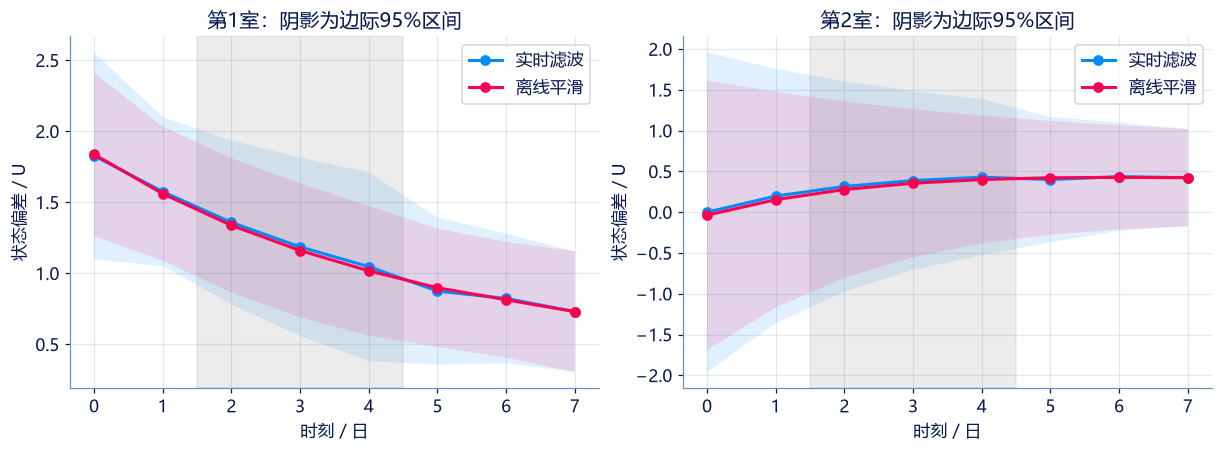

In [4]:
F=np.array([[.85,.1],[.1,.8]]);H=np.array([1.,0.]);Q=.02*np.eye(2);R=.16;m0=np.array([2.,0.]);P0=np.eye(2);observed=[1.8,1.6,None,None,None,.8,.9,.7]
filtered=kalman_filter(F,H,Q,R,m0,P0,observed)
smooth=rts_smooth(F,filtered['predicted_means'],filtered['predicted_covariances'],filtered['means'],filtered['covariances'])
fig,axes=plt.subplots(1,2,figsize=(11,4),sharex=True)
for i,ax in enumerate(axes):
    for result,label in [(filtered,'实时滤波'),(smooth,'离线平滑')]:
        means=np.array(result['means'])[:,i];sd=np.sqrt(np.array(result['covariances'])[:,i,i]);ax.plot(means,marker='o',label=label);ax.fill_between(np.arange(len(means)),means-1.96*sd,means+1.96*sd,alpha=.12)
    ax.axvspan(1.5,4.5,color='gray',alpha=.15);ax.set(xlabel='时刻 / 日',ylabel='状态偏差 / U',title=f'第{i+1}室：阴影为边际95%区间');ax.legend()
plt.show()

### 独立核验与边界

In [5]:
# 从独立初态与过程增量构造整段状态的线性载荷，不使用KF递推。
T=len(observed);n=2;loading=np.zeros((n*T,n*T));sources=np.zeros((n*T,n*T));sources[:n,:n]=P0
for j in range(1,T):sources[j*n:(j+1)*n,j*n:(j+1)*n]=Q
prior_mean=np.concatenate([np.linalg.matrix_power(F,t)@m0 for t in range(T)])
for t in range(T):
    loading[t*n:(t+1)*n,:n]=np.linalg.matrix_power(F,t)
    for j in range(1,t+1):loading[t*n:(t+1)*n,j*n:(j+1)*n]=np.linalg.matrix_power(F,t-j)
joint=loading@sources@loading.T;kept=[t for t,y in enumerate(observed) if y is not None];design=np.zeros((len(kept),n*T))
for row,t in enumerate(kept):design[row,t*n:(t+1)*n]=H
S=design@joint@design.T+R*np.eye(len(kept));cross=joint@design.T
expected=prior_mean+cross@np.linalg.solve(S,np.array([observed[t] for t in kept])-design@prior_mean)
expected_cov=joint-cross@np.linalg.solve(S,cross.T)
np.testing.assert_allclose(smooth['means'],expected.reshape(T,n),atol=1e-12)
for t in range(T):
    np.testing.assert_allclose(smooth['covariances'][t],expected_cov[t*n:(t+1)*n,t*n:(t+1)*n],atol=1e-12)
    assert np.linalg.eigvalsh(np.array(filtered['covariances'][t])-smooth['covariances'][t]).min()>-1e-12
np.testing.assert_allclose(smooth['means'][-1],filtered['means'][-1])
no_obs=kalman_filter(F,H,Q,R,m0,P0,[None]*T);no_smooth=rts_smooth(F,no_obs['predicted_means'],no_obs['predicted_covariances'],no_obs['means'],no_obs['covariances']);np.testing.assert_allclose(no_smooth['means'],no_obs['means'])
print('整段联合条件的均值和协方差、末端一致性、全缺测以及半正定顺序通过。')

整段联合条件的均值和协方差、末端一致性、全缺测以及半正定顺序通过。


## 结果解释

两种方法使用同一模型，区别来自信息到达时间。恢复后的传感器读数可以改善缺测段的离线重建；实时滤波在当时还没有这些后续读数。将平滑结果与整段联合 Gaussian 条件分布比较，可以核对两室均值与交叉协方差。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：由已保存的滤波矩后向平滑

给定每时刻预测和滤波矩，用固定区间RTS递推计算平滑均值和协方差（covariance）。末时刻保持滤波结果。

**函数与代码模板**

```python
def solve(
    transition: list[list[float]],
    predicted_means: list[list[float]],
    predicted_covariances: list[list[list[float]]],
    means: list[list[float]],
    covariances: list[list[list[float]]],
) -> tuple[list[list[float]], list[list[list[float]]]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `transition` | `list[list[float]]` | 已知状态（state）转移矩阵（transition matrix） F。 | 无量纲 |
| `predicted_means` | `list[list[float]]` | 每时刻观测（observation）前的均值，长度 T。 | U |
| `predicted_covariances` | `list[list[list[float]]]` | 每时刻观测前协方差。 | U² |
| `means` | `list[list[float]]` | 每时刻滤波后的均值。 | U |
| `covariances` | `list[list[list[float]]]` | 每时刻滤波后的协方差。 | U² |

**返回值**

按以下顺序返回元组：(means, covariances)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `means` | `list[list[float]]` | 各时刻在给定整段观测后的固定区间平滑均值，可利用该时刻之后的观测。 | U |
| `covariances` | `list[list[list[float]]]` | 与 means 对应的固定区间平滑协方差矩阵（covariance matrix）。 | U² |

**计算规则**

G[t]=P_f[t] Fᵀ inv(P_pred[t+1])；m_s[t]=m_f[t]+G[t] * (m_s[t+1]−m_pred[t+1])；P_s[t]=P_f[t]+G[t] * (P_s[t+1]−P_pred[t+1])G[t]ᵀ。从T−2向0递推；T=0返回两个空列表。

**约束与边界**

- 状态维数1或2，T为0—20，所有数组（array）时刻数相同。
- 输入（input）来自同一合法线性高斯滤波；非空预测协方差正定（positive definite）；值有限。
- 不得用predicted[t]替代predicted[t+1]，不得在平滑中重新吸收观测。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| transition | 已知状态（state）转移矩阵（transition matrix） F。 | [[1.0]] | 无量纲 |
| predicted_means | 每时刻观测（observation）前的均值，长度 T。 | [[0.0], [1.6], [1.6]] | U |
| predicted_covariances | 每时刻观测前协方差。 | [[[4.0]], [[0.9]], [[1.0]]] | U² |
| means | 每时刻滤波后的均值。 | [[1.6], [1.6], [1.3]] | U |
| covariances | 每时刻滤波后的协方差。 | [[[0.8]], [[0.9]], [[0.5]]] | U² |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
transition = [[1.0]]
predicted_means = [[0.0], [1.6], [1.6]]
predicted_covariances = [[[4.0]], [[0.9]], [[1.0]]]
means = [[1.6], [1.6], [1.3]]
covariances = [[[0.8]], [[0.9]], [[0.5]]]

result = solve(transition, predicted_means, predicted_covariances, means, covariances)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| means | 各时刻在给定整段观测后的固定区间平滑均值，可利用该时刻之后的观测。 | [[1.36], [1.33], [1.3]] | U |
| covariances | 与 means 对应的固定区间平滑协方差矩阵（covariance matrix）。 | [[[0.48]], [[0.495]], [[0.5]]] | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[1.36], [1.33], [1.3]],
                   [[[0.48]], [[0.495]], [[0.5]]])
```

**样例解释**

样例的中间时刻缺测，但后来的读数能回传信息；最后时刻均值和协方差与滤波完全一致。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：由已保存的滤波矩后向平滑](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-rts-backward)

### 第 2 题 · 多项选择题：后向递推在哪里开始

关于固定区间RTS平滑，哪些正确？

- **A.** 末时刻平滑等于滤波。
- **B.** 只有一个时刻时不做后向更新。
- **C.** 缺测时必须把状态（state）设为0。
- **D.** 后向增益（gain）用下一时刻预测协方差（covariance）。

[作答：后向递推在哪里开始](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-terminal-equality)

### 第 3 题 · 单项选择题：协方差变小的前提

相同正确线性高斯模型（model）、相同已知噪声和同一组观测（observation）下，哪项正确？

- **A.** 平滑协方差（covariance）不大于滤波协方差，按半正定（positive semidefinite）顺序理解。
- **B.** 每次随机实验的实际误差必逐点更小。
- **C.** 两个不同错误模型的协方差也必须满足同样顺序。
- **D.** 更小模型协方差自动证明对现实更准确。

[作答：协方差变小的前提](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-covariance-order)

### 第 4 题 · 多项选择题：缺测区间里的误差

某段连续缺测，之后传感器恢复。哪些正确？

- **A.** 滤波在缺测段只做动态预测。
- **B.** 平滑可利用恢复后的读数修正缺测段。
- **C.** 把平滑估计写进实时评估会引入未来信息。
- **D.** 缺测意味着过程噪声（process noise）也停止。

[作答：缺测区间里的误差](http://127.0.0.1:8000/chapters/07-06-%E5%B9%B3%E6%BB%91%E4%B8%8E%E7%BC%BA%E6%B5%8B%E5%A4%84%E7%90%86/practice/?question=p07-missing-gap)

### 延伸阅读

R26，第12章线性Gaussian平滑。 [Särkkä 与 Svensson，《Bayesian Filtering and Smoothing》第二版，2023](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf)。本节公式、实现和核验可独立阅读；参考资料用于进一步学习。

[概念探索与交互](http://127.0.0.1:8000/chapters/07-06-平滑与缺测处理/explore/) · [本篇目录](../README.md)